In [19]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# Lon period (1960-2025)

In [20]:
iyear = 2000
fyear = 2019

# Short period with glacier evolution data (2000-2019)

In [21]:
iyear2 = 1960
fyear2 = 2019

# Atmospheric variables

In [22]:
variables = ['t2m','FLH','tcwv','ivt','sf']

# Subregions with glacier evolution data

In [23]:
domains = ["Tien Shan", "Pamir Alay", "Pamir", "Hindu Kush", "Karakoram", 
           "Kunlun", "Spiti Lahaul", "Central Himalaya","Bhutan", "Nyainqentangla", "Inner TP"]

# Short period data loading

Monthly trends of the different armospheric variables in the subregions were computed in : /Stage M2/papier/compute_monthly-trends_var_era5_HIMAPgrouped_final_regions.py for t2m & FLH. For tcwv, ivt & sf in : /Stage M2/papier/compute_monthly-percentage_trends_var_era5_HIMAPgrouped_final_regions.py

In [24]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'] # month of the year
path = '/bettik/PROJECTS/pr-regional-climate/bricej/paper/' # path to the data

var_trends = {} # dictionnary to store short period data

for var in variables:
    var_trends[var] = {}
    for month in months :
        monthly_trends = pd.read_csv(f'{path}{var}_era5_{month}_trends_HIMAPgrouped_regions_{iyear}-{fyear}.csv')
        var_trends[var][month] = monthly_trends

# stocker valeur de la pente
var_slopes = {}
for var in variables:
    var_slopes[var] = {}
    for dom in domains:
        var_slopes[var][dom] = {}
        for month in months:
            var_slopes[var][dom][month] = var_trends[var][month].loc[var_trends[var][month]['region'] == dom, 'slope'].values[0] * 10 # *10 -> per decade

# stocker valeur de la pvalue
var_pvalue = {}
for var in variables:
    var_pvalue[var] = {}
    for dom in domains:
        var_pvalue[var][dom] = {}
        for month in months:
            var_pvalue[var][dom][month] = var_trends[var][month].loc[var_trends[var][month]['region'] == dom, 'pvalue'].values[0]

# Long period data loading

In [25]:
var_trends_all_period = {} # dictionnary to store long period data

for var in variables:
    var_trends_all_period[var] = {}
    for month in months :
        monthly_trends = pd.read_csv(f'{path}{var}_era5_{month}_trends_HIMAPgrouped_regions_{iyear2}-{fyear2}.csv')
        var_trends_all_period[var][month] = monthly_trends

# stocker valeur de la pente
var_slopes_all_period = {}
for var in variables:
    var_slopes_all_period[var] = {}
    for dom in domains:
        var_slopes_all_period[var][dom] = {}
        for month in months:
            var_slopes_all_period[var][dom][month] = var_trends_all_period[var][month].loc[var_trends_all_period[var][month]['region'] == dom, 'slope'].values[0] * 10 # *10 -> per decade

# stocker valeur de la pvalue
var_pvalue_all_period = {}
for var in variables:
    var_pvalue_all_period[var] = {}
    for dom in domains:
        var_pvalue_all_period[var][dom] = {}
        for month in months:
            var_pvalue_all_period[var][dom][month] = var_trends_all_period[var][month].loc[var_trends_all_period[var][month]['region'] == dom, 'pvalue'].values[0]

# Percentage trend for tcwv, ivt, sf

In [30]:
## Short period

In [ ]:
## Long period

# Saison d'accumulation

Mois qui recoivent plus de 8% du total tp annuel. For more details : /StageM2_IVT/papier/Annual_Cycle_var_mean_1960-2019_HIMAPgrouped_final.py (last cell)

In [26]:
tp_season = {"Tien Shan" : ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep'],
        "Pamir Alay" : ['Mar', 'Apr', 'May', 'Jun', 'Jul'],
        "Pamir" : ['Feb', 'Mar', 'Apr', 'May', 'Dec'],
        "Hindu Kush" : ['Feb', 'Mar', 'Apr', 'May', 'Jul', 'Aug'],
        "Karakoram" : ['Feb', 'Mar', 'Apr', 'Jul', 'Aug'],
        "Kunlun" : ['May', 'Jun', 'Jul', 'Aug', 'Sep'],
        "Spiti Lahaul" : ['Feb', 'Mar', 'Apr', 'Jul', 'Aug'],
        "Central Himalaya" : ['Jun', 'Jul', 'Aug', 'Sep'],
        "Bhutan" : ['May', 'Jun', 'Jul', 'Aug', 'Sep'],
        "Nyainqentangla" : ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep'],
        "Inner TP" : ['May', 'Jun', 'Jul', 'Aug', 'Sep']}

# for the plot later we associate the number with the month
month_to_num = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4,
    'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8,
    'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

# Final plot : Annual cycle of trends of atmospheric variables

NameError: name 'tp_season2' is not defined

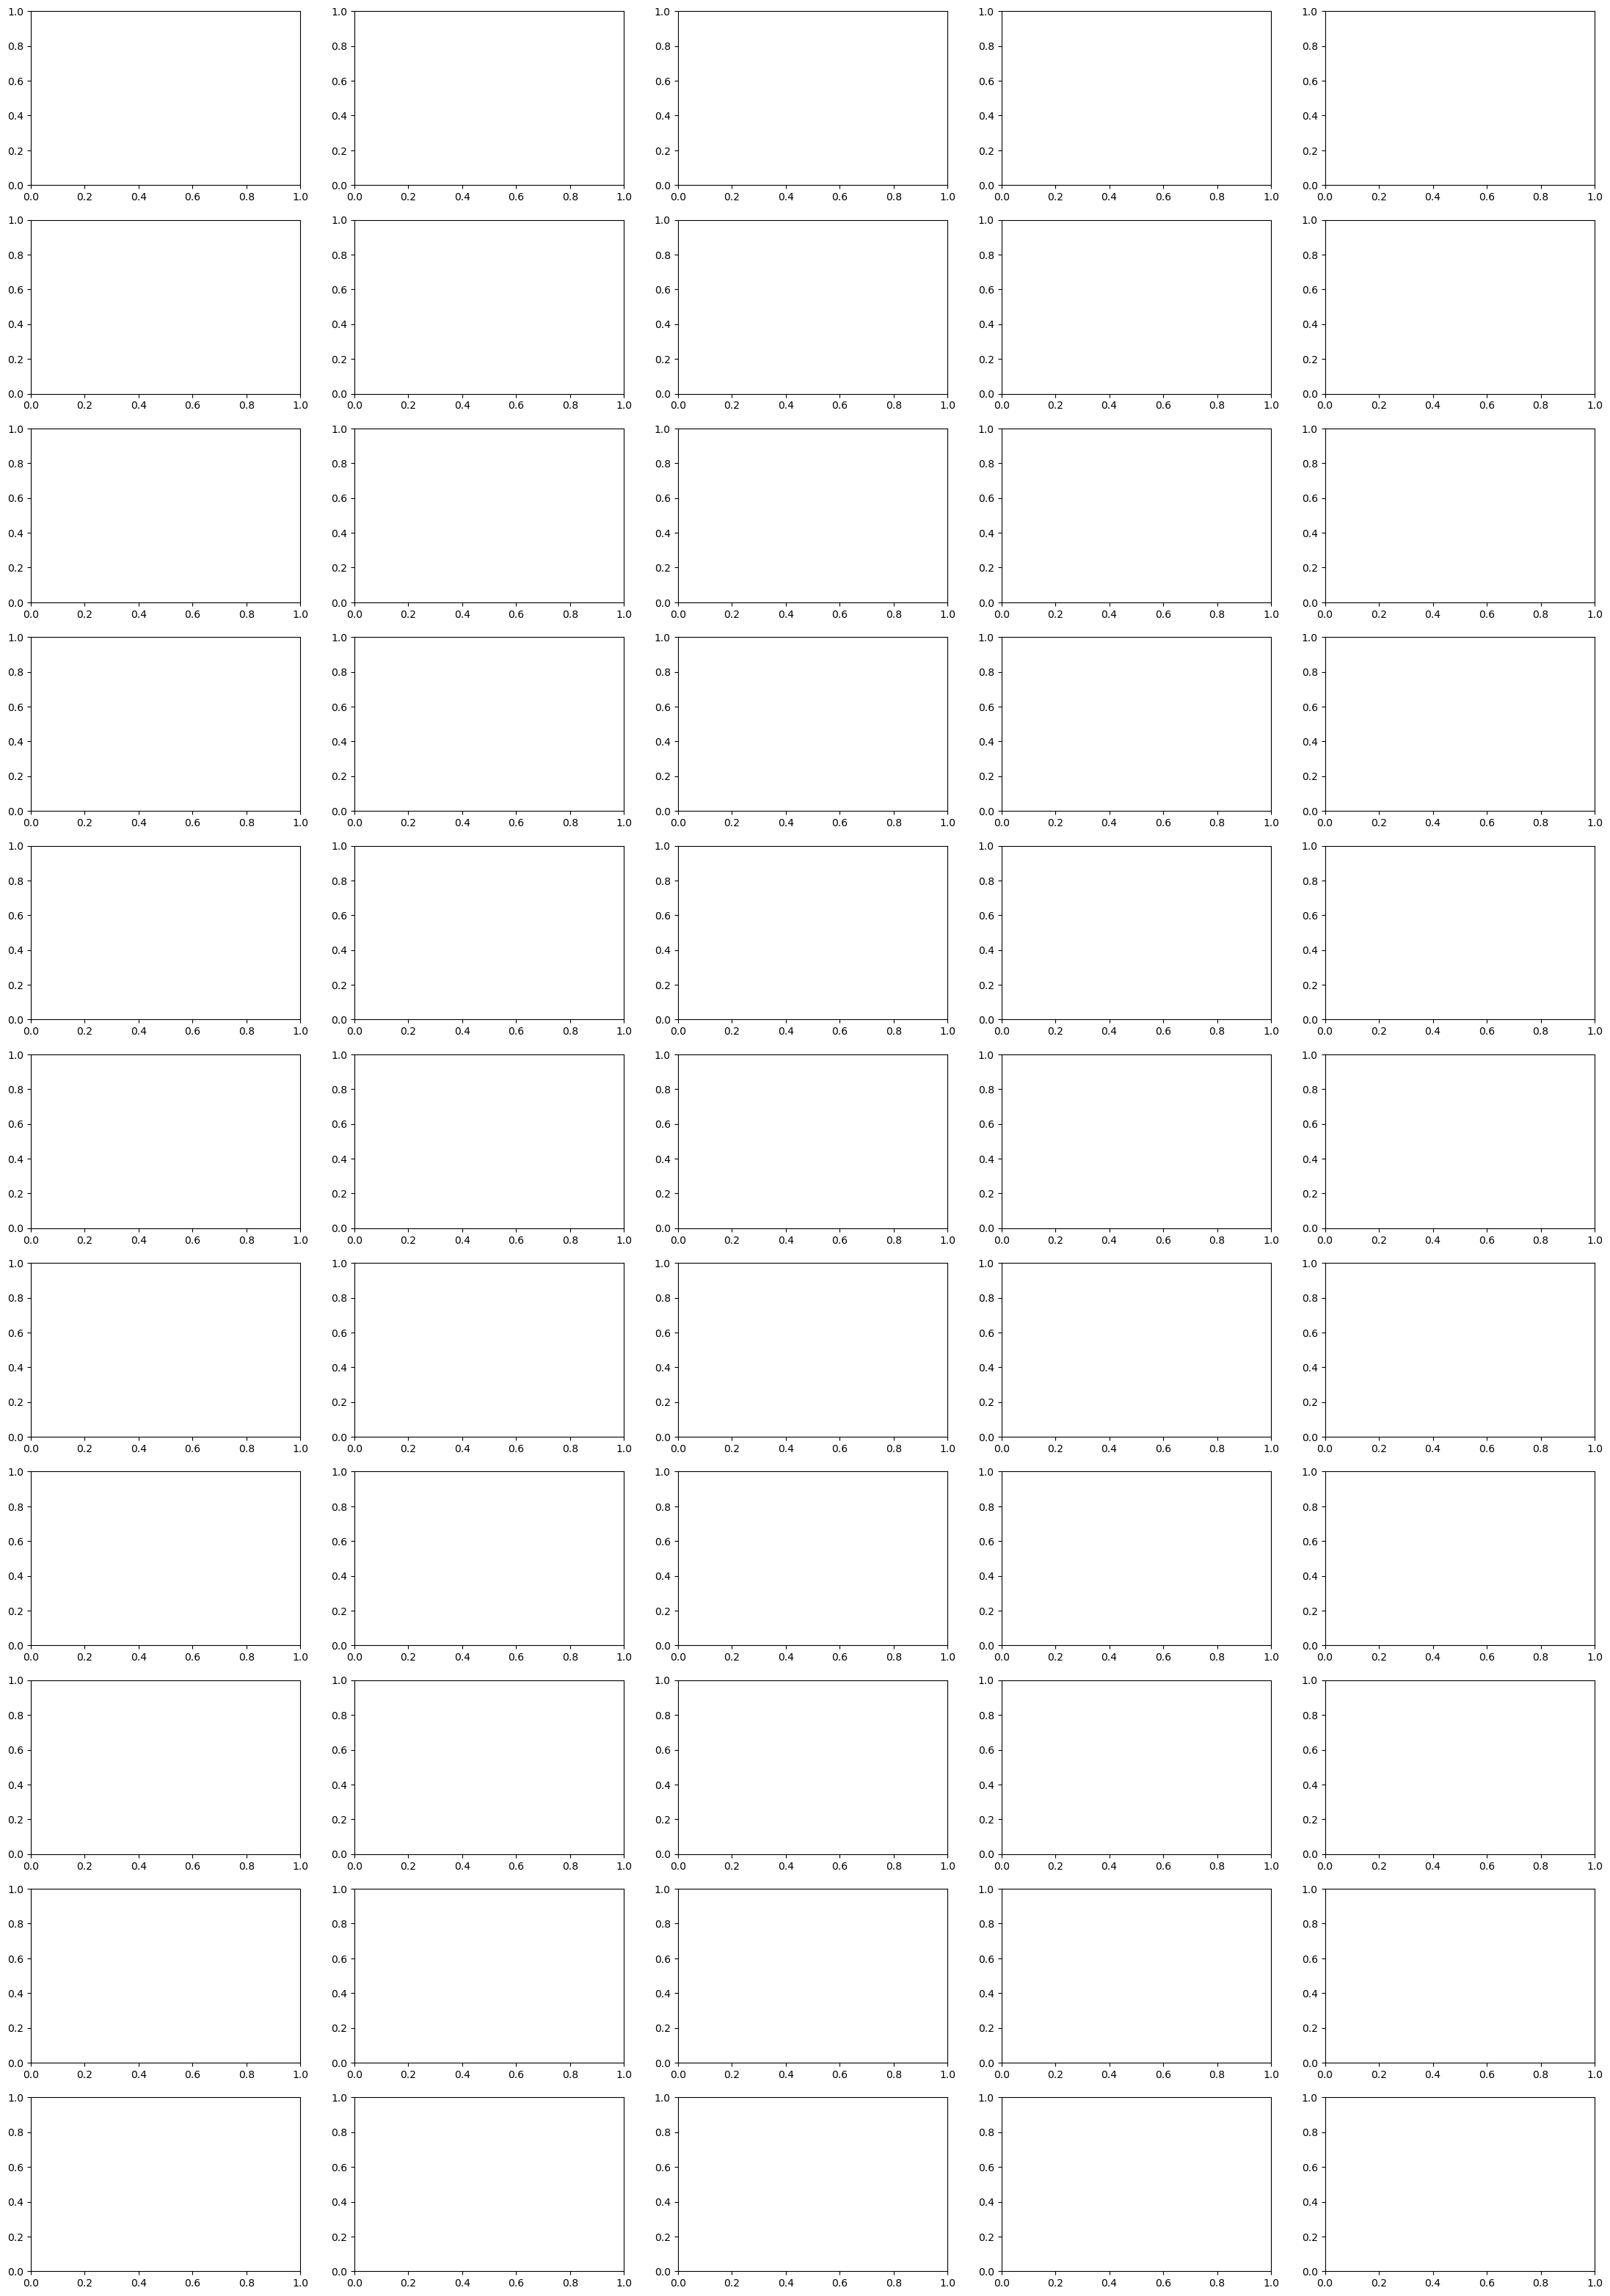

In [29]:
# colors of atmospheric variables dans l'ordre
colors_final = ['red','orange','blue','lightseagreen','violet',]

# figure
fig, axes = plt.subplots(11, 5, figsize=(27.5, 40))

# limites Y communes par colonne 
ylims = {}
for var in variables:
    all_slopes = []
    for dom in domains:
        all_slopes.extend([var_slopes2[var][dom][m] for m in months])
    ymin = min(all_slopes)
    ymax = max(all_slopes)
    margin = 0.075 * (ymax - ymin)
    ylims[var] = (ymin - margin, ymax + margin)

# matrice des subplots
for i, dom in enumerate(domains): # ligne : domain
    for j, var in enumerate(variables): # colonne : variable
    
        ax = axes[i, j]
        color = colors_final[j]
            
        # saison de tp
        tp_months = tp_season[dom]
        tp_nums = [month_to_num[m] for m in tp_months]
    
        # trends stats (courte période)
        slopes = [var_slopes2[var][dom][m] for m in months]
        pvalues = [var_pvalue2[var][dom][m] for m in months]
    
        # all period 1960-2019 (longue période)
        slopes_all_period = [var_slopes_all_period2[var][dom][m] for m in months]
        pvalues_all_period = [var_pvalue_all_period2[var][dom][m] for m in months]
    
        # y lim pour chaque colonne
        ax.set_ylim(ylims[var])
        if var == 'FLH':
            ax.set_yticks(np.arange(-100, 200, 50))
        
        # Calcul de l'offset pour espacer l'étoile de la barre (étoile = p-value < 0.05)
        y_range = ylims[var][1] - ylims[var][0]
        offset = 0.02 * y_range
    
        # 0 value
        ax.axhline(y=0, linestyle='-', linewidth=2, color='black', alpha=1, zorder=10)
            
        # mean value of slopes - courte période
        mean = np.mean(slopes)
        ax.axhline(y=mean, linestyle='-', linewidth=1.9, color=color, alpha=1, zorder=10)
    
        # mean value of slopes 1960-2019 - longue période
        mean2 = np.mean(slopes_all_period)
        ax.axhline(y=mean2, linestyle='--', linewidth=1.8, color=color, alpha=0.9, zorder=10)
            
        # Construction du barplot juxtaposé
        width = 0.35  # largeur de chaque barre
        for m_idx, month_num in enumerate(range(1, 13)): # m_idx de 0 à 11 et month_num de 1 à 12
            
            # longue période (alpha=0.5 constant)
            p_long = pvalues_all_period[m_idx]
            val_long = slopes_all_period[m_idx]
            ax.bar(month_num - width/2,val_long,width,color=color,alpha=0.5,edgecolor='none')
            
            # Étoile si p-value significative
            if p_long <= 0.05:
                y_star = val_long + offset if val_long >= 0 else val_long - (2.5*offset)
                ax.text(month_num - width/2, y_star, '*', color='black',fontsize=16, fontweight='bold',ha='center', va='center',zorder=10)
            
            # courte période (alpha=1.0 constant)
            p_short = pvalues[m_idx]
            val_short = slopes[m_idx]
            
            ax.bar(month_num + width/2,val_short,width,color=color,alpha=1.0,edgecolor='none')
            
            # Étoile si p-value significative
            if p_short <= 0.05:
                y_star = val_short + offset if val_short >= 0 else val_short - (2.5*offset)
                ax.text(month_num + width/2, y_star, '*', color='black', fontsize=16, fontweight='bold',ha='center', va='center',zorder=10)
    
        # shading pour tp months (accumulation season)
        for m in tp_nums:
            ax.axvspan(m - 0.5,m + 0.5,color='lightgray',alpha=0.6,zorder=0,ec=None)
        
        # Titre des variables : uniquement tout en haut (première ligne)
        if i == 0:
            ax.set_title(var, fontsize=18, weight='bold')
            
        # Noms des régions (domaines) : à gauche de la première colonne, pivoté à 90°
        if j == 0:
            ax.set_ylabel(dom, fontsize=18, weight='bold', rotation=90, labelpad=10)
    
        # label des mois 
        ax.set_xticks(range(1, 13))
    
        # yticks & labelticks partout
        ax.tick_params(axis='y', labelleft=True, labelsize=16)
        ax.tick_params(axis='x', labelsize=16)
            
        ax.grid(True, linestyle='--', alpha=0.5)


plt.tight_layout(rect=[0, 0.02, 1, 1]) # Ajustement léger de l'espace bas
plt.show()